In [1]:
import torch
import numpy as np
import timesfm
from huggingface_hub import snapshot_download
from tqdm.notebook import tqdm
import os

# Optional: see what's being downloaded
os.environ["HUGGINGFACE_HUB_VERBOSITY"] = "info"

torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)


/Users/ramin/Documents/Developer/timesfm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded.


In [2]:
x = np.linspace(0, 20, 67)
inputs = [
    np.linspace(0, 1, 100),
    np.sin(x) / x,
]

point_forecast, quantile_forecast = model.forecast(
    horizon=12,
    inputs=inputs,  
)
point_forecast.shape  # (2, 12)
quantile_forecast.shape  # (2, 12, 10): mean, then 10th to 90th quantiles.

/var/folders/bs/xy4plrkx1jg7psxbdl4vvcth0000gn/T/ipykernel_82814/1342870539.py:4: RuntimeWarning: invalid value encountered in divide
  np.sin(x) / x,


(2, 12, 10)

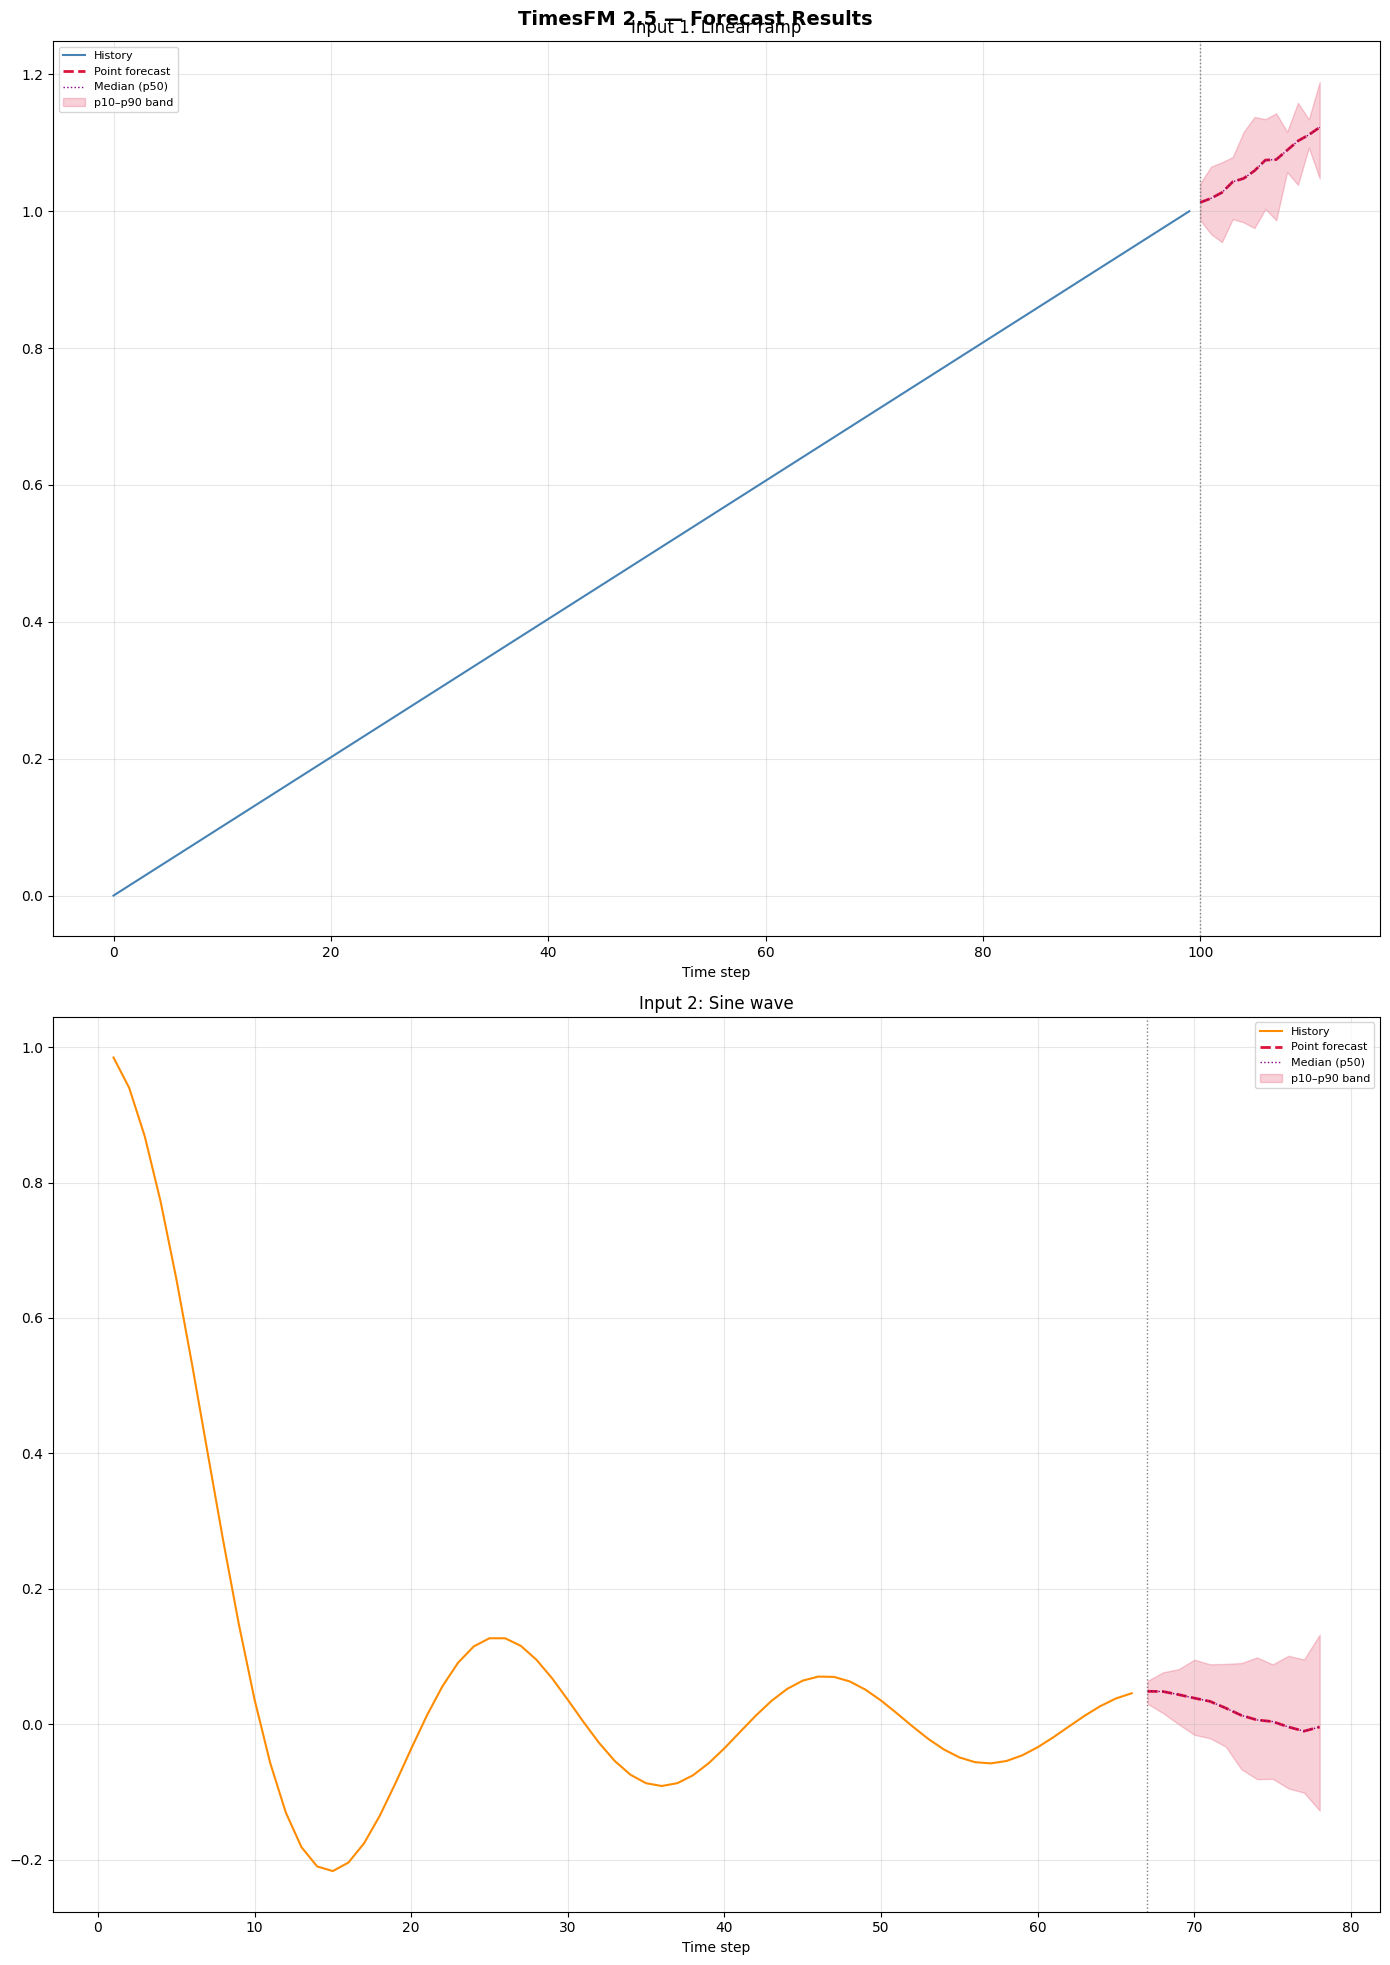

In [3]:
import matplotlib.pyplot as plt
import numpy as np


titles = ['Input 1: Linear ramp', 'Input 2: Sine wave']
colors = ['steelblue', 'darkorange']

fig, axes = plt.subplots(2, 1, figsize=(14, 20))
fig.suptitle('TimesFM 2.5 — Forecast Results', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    hist = inputs[i]
    horizon = point_forecast.shape[1]
    x_hist  = np.arange(len(hist))
    x_fcast = np.arange(len(hist), len(hist) + horizon)

    # Quantile indices: 1=p10, 5=p50, 9=p90
    q_low = quantile_forecast[i, :, 1]
    q_mid = quantile_forecast[i, :, 5]
    q_high = quantile_forecast[i, :, 9]

    ax.plot(x_hist, hist, color=colors[i], linewidth=1.5, label='History')
    ax.plot(x_fcast, point_forecast[i], color='crimson', linewidth=2, linestyle='--', label='Point forecast')
    ax.plot(x_fcast, q_mid, color='purple', linewidth=1, linestyle=':', label='Median (p50)')
    ax.fill_between(x_fcast, q_low, q_high, alpha=0.2, color='crimson', label='p10–p90 band')
    ax.axvline(len(hist), color='gray', linestyle=':', linewidth=1)
    ax.set_title(titles[i])
    ax.set_xlabel('Time step')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Example with Covariants

In [5]:
import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=7,
        max_horizon=7,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        return_backcast=True,
    )
)
# Example data for two products (ice cream and sunscreen)
inputs = [[30, 30, 4, 5, 7, 8, 10],    # observed sales (7 days)
          [5, 7, 12, 13, 5, 6, 10]]
# dynamic covariates must include both past 7 days and the next 7 days (total 14)
dynamic_categorical_covariates = {
    "Weekday": [[0,1,2,3,4,5,6, 0,1,2,3,4,5,6],
                [0,1,2,3,4,5,6, 0,1,2,3,4,5,6]],
    "Has_promotion": [[1,1,0,0,0,1,1, 0,0,0,0,0,0,0],
                      [0,0,1,1,0,0,0, 1,1,1,1,1,1,1]]
}
dynamic_numerical_covariates = {
    "Daily_temperature": [[31.0,24.3,19.4,26.2,24.6,30.0,31.1,
                           32.4,30.9,26.0,25.0,27.8,29.5,31.2],
                          [31.0,24.3,19.4,26.2,24.6,30.0,31.1,
                           32.4,30.9,26.0,25.0,27.8,29.5,31.2]]
}
static_categorical_covariates = {"Category": ["food", "skin product"]}
static_numerical_covariates = {"Base_price": [1.99, 29.99]}

# Forecast with covariates (using default “xreg + timesfm” mode)
cov_forecast, linear_forecast = model.forecast_with_covariates(
    inputs=inputs,
    dynamic_numerical_covariates=dynamic_numerical_covariates,
    dynamic_categorical_covariates=dynamic_categorical_covariates,
    static_numerical_covariates=static_numerical_covariates,
    static_categorical_covariates=static_categorical_covariates,
    # freq=[0, 0],       # frequency indicator (0 for arbitrary)
    xreg_mode="timesfm + xreg",  # or "timesfm + xreg"
    ridge=0.0,
    normalize_xreg_target_per_input=True
)

print("TSFM forecast with exogenous variables:", cov_forecast)

Downloaded.


ValueError: operands could not be broadcast together with shapes (7,) (0,) 